In [1]:
import os
import sys
from dotenv import load_dotenv
load_dotenv() 

# Set the target folder name you want to reach
target_folder = "NCEAS_Unsupervised_NLP"

# Get the current working directory
current_dir = os.getcwd()

# Loop to move up the directory tree until we reach the target folder
while os.path.basename(current_dir) != target_folder:
    parent_dir = os.path.abspath(os.path.join(current_dir, ".."))
    if parent_dir == current_dir:
        # If we reach the root directory and haven't found the target, exit
        raise FileNotFoundError(f"{target_folder} not found in the directory tree.")
    current_dir = parent_dir

# Change working directory to the project root
os.chdir(current_dir)

# Add the "NCEAS_Unsupervised_NLPt" directory to sys.path
sys.path.insert(0, current_dir)

In [28]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import seaborn as sns
import ipywidgets as widget
from itertools import cycle
import json
import itertools
from sklearn.metrics import adjusted_mutual_info_score

In [29]:
embedding_models = [
    "Qwen3-Embedding-0.6B",
    "all-MiniLM-L6-v2"
]

In [30]:

params = [
    {'theme': None, 't': 1.0, 'maxsub': 5, 'depth': 3, 'synonyms': None, 'noise': None, 'branching': 'random'},
    {'theme': None, 't': 1.0, 'maxsub': 3, 'depth': 5, 'synonyms': None, 'noise': None, 'branching': 'random'},
    # {'theme': None, 't': 1.0, 'maxsub': 5, 'depth': 3, 'synonyms': 10,'noise': None, '': 'random'},
    # {'theme': None, 't': 1.0, 'maxsub': 5, 'depth': 3, 'synonyms': 0,'noise': None, '': 'random'},
    # {'theme': None, 't': 1.0, 'maxsub': 3, 'depth': 5, 'synonyms': 10,'noise': None, '': 'random'},
    # {'theme': None, 't': 1.0, 'maxsub': 3, 'depth': 5, 'synonyms': 0,'noise': None, '': 'random'},
    # {'theme': "Energy, Ecosystems, and Humans", 't': 1.0, 'maxsub': 3, 'depth': 5,'synonyms':10,'noise':0.25,'':'random'},
    # # {'theme': "Energy, Ecosystems, and Humans", 't': 1.0, 'maxsub': 5, 'depth': 3, 'synonyms': None, '': 'random'},
    # {'theme': "Offshore energy impacts on fisheries", 't': 1.0, 'maxsub': 3, 'depth': 5,'synonyms':10,'noise':0.25,'':'random'},
    # # {'theme': "Offshore energy impacts on fisheries", 't': 1.0, 'maxsub': 5, 'depth': 3,'synonyms':10,'noise':0.25,'':'random'},
    # {'theme': "West Java, Indonesia", 't': 1.0, 'maxsub': 3, 'depth': 5, 'synonyms':10,'noise':0.25,'':'random'},
    # # {'theme': "West Java, Indonesia", 't': 1.0, 'maxsub': 5, 'depth': 3, 'synonyms': None, '': 'random'},

    # # Additional entries with noise=0.25
    # {'theme': None, 't': 1.0, 'maxsub': 5, 'depth': 3, 'synonyms': None,'noise': 0.25, '': 'random'},
    # {'theme': None, 't': 1.0, 'maxsub': 3, 'depth': 5, 'synonyms': None,'noise': 0.25, '': 'random'},
    # {'theme': None, 't': 1.0, 'maxsub': 5, 'depth': 3, 'synonyms': None,'noise': 0.0, '': 'random'},
    # {'theme': None, 't': 1.0, 'maxsub': 3, 'depth': 5, 'synonyms': None,'noise': 0.0, '': 'random'},
    # {'theme':None,'t':1.0,'maxsub':3,'depth':5,'synonyms':10,'noise':0.25,'':'random'}
]


# params = [{'theme':None,'t':1.0,'maxsub':3,'depth':5,'synonyms':10,'noise':0.25,'':'random'}]

In [31]:
import os
print(os.getcwd())

/Users/sukainaalkhalidy/Desktop/CMSE 495 capstone/NCEAS_Unsupervised_NLP


In [32]:
import json

with open('src/evaluations/combo_color_map.json', 'r') as file:
    combo_color_map = json.load(file)

In [33]:
for embedding in embedding_models:

    for param_lst in params:

        ...

        print("Loading:", bertopic_file)

        if not os.path.exists(bertopic_file):
            print("File missing:", bertopic_file)
            continue

        bertopic_results = pd.read_csv(bertopic_file)

Loading: all-MiniLM-L6-v2_results/all_MiniLM_other_arxiv_results.csv
Loading: all-MiniLM-L6-v2_results/all_MiniLM_other_arxiv_results.csv
Loading: all-MiniLM-L6-v2_results/all_MiniLM_other_arxiv_results.csv
Loading: all-MiniLM-L6-v2_results/all_MiniLM_other_arxiv_results.csv


In [34]:
import os

print(os.listdir("Qwen3-Embedding-0.6B_results"))

['qwen3_arxiv_results.csv']


In [35]:
import pandas as pd

df = pd.read_csv("Qwen3-Embedding-0.6B_results/qwen3_arxiv_results.csv")
print(df.head())

  reduction_method cluster_method  level        FM      Rand       ARI
0              PCA  Agglomerative      2  0.933393  0.911201  0.800560
1              PCA  Agglomerative     62  0.213036  0.933818  0.157418
2              PCA             DC      2  0.591714  0.506226 -0.016413
3              PCA             DC     62  0.226867  0.917260  0.181618
4              PCA        HDBSCAN      2  0.810250  0.656527 -0.000048


Loading: Qwen3-Embedding-0.6B_results/qwen3_arxiv_results.csv


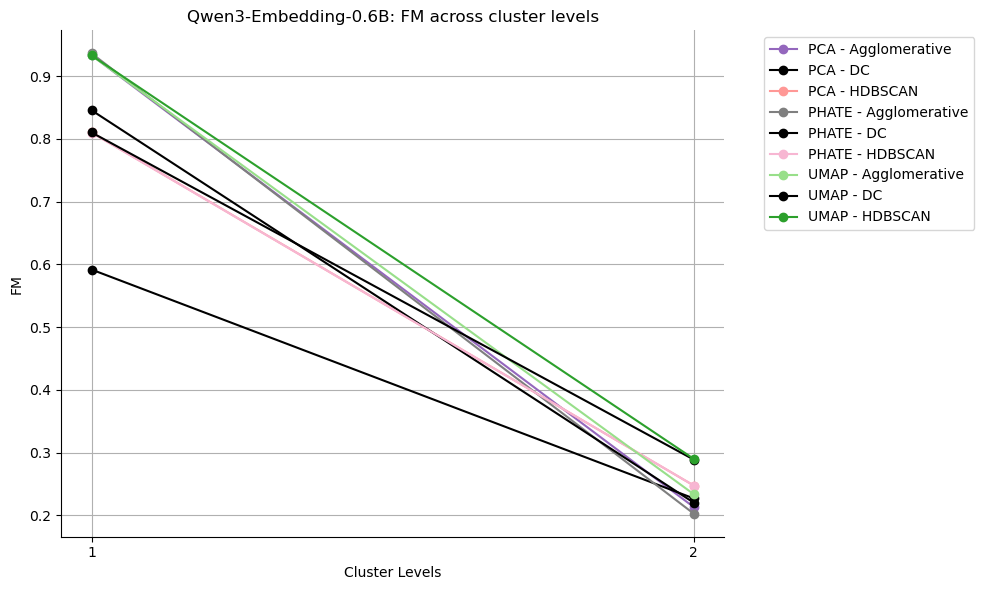

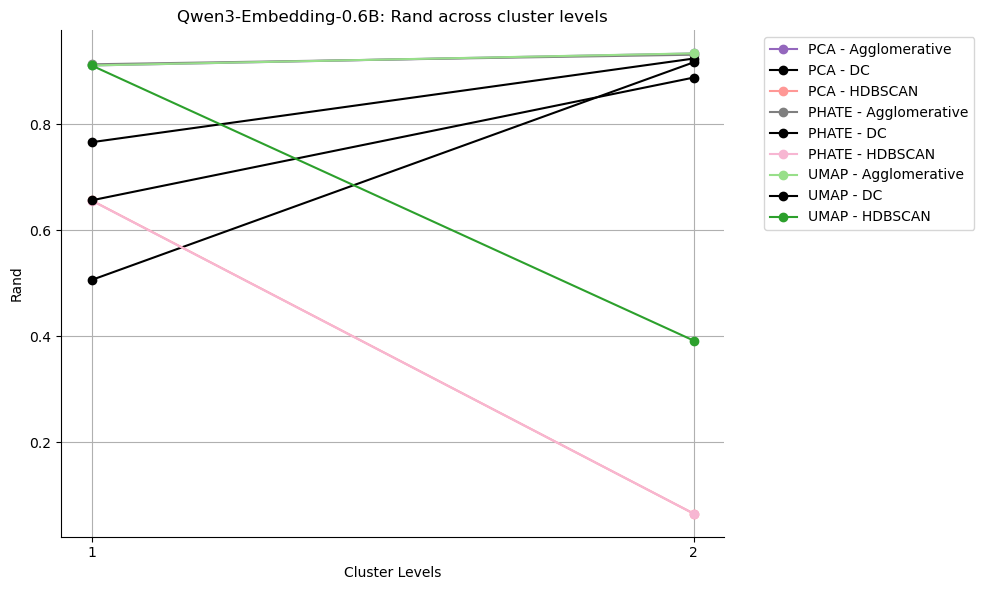

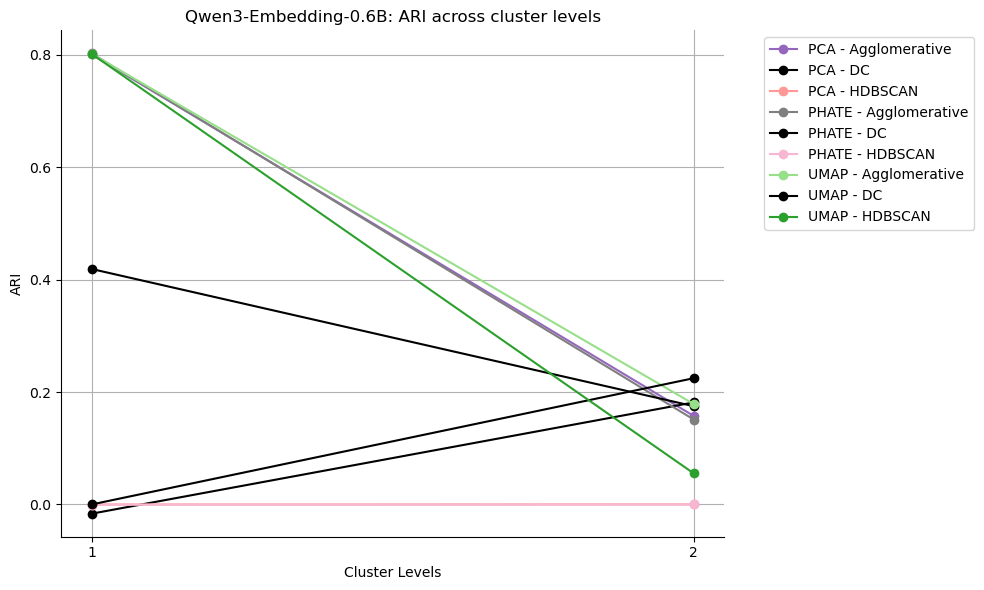

Loading: all-MiniLM-L6-v2_results/all_MiniLM_other_arxiv_results.csv


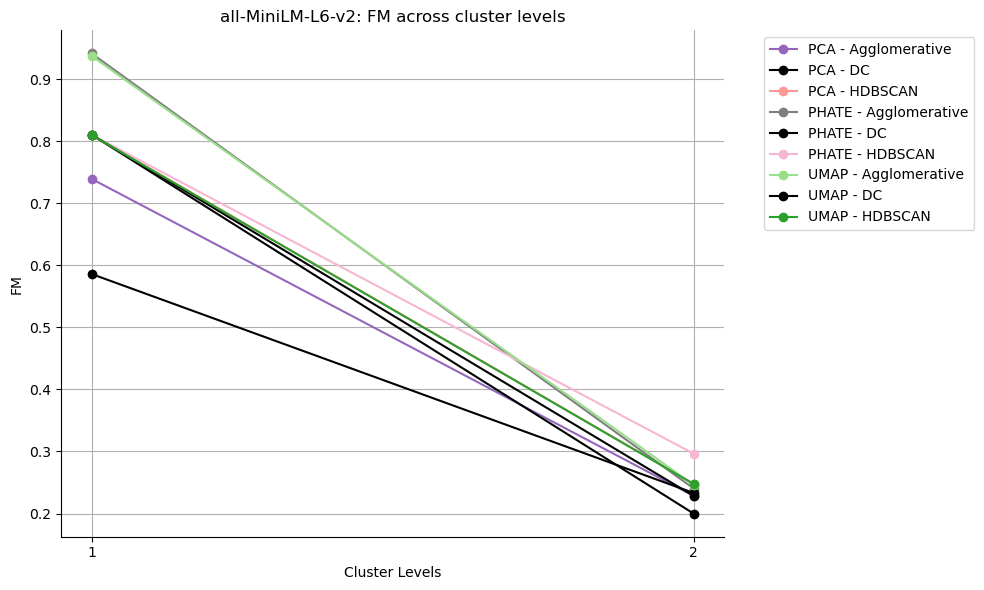

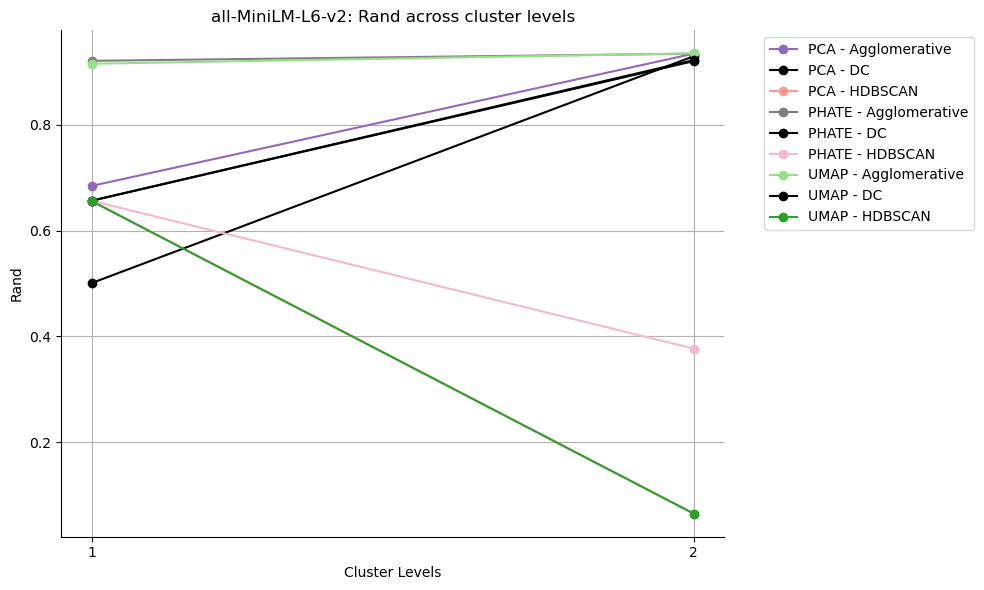

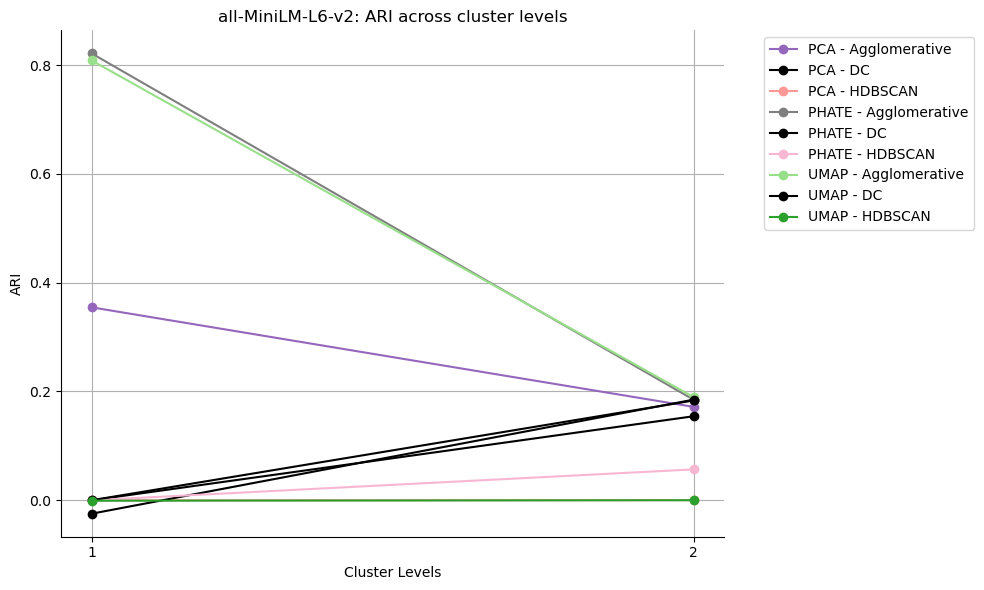

In [39]:
for embedding in embedding_models:

    results_folder = f"{embedding}_results"

    # Find CSV file automatically
    files = os.listdir(results_folder)
    csv_files = [f for f in files if f.endswith(".csv")]

    if not csv_files:
        print("No CSV file found for", embedding)
        continue

    bertopic_file = f"{results_folder}/{csv_files[0]}"

    print("Loading:", bertopic_file)

    bertopic_results = pd.read_csv(bertopic_file)

    bertopic_results['reduction_method'] = bertopic_results['reduction_method'].fillna("None")

    # ADD AMI HERE
    scores_to_plot = ['FM', 'Rand', 'ARI', 'AMI']

    # Only keep scores that exist in the CSV
    scores_to_plot = [s for s in scores_to_plot if s in bertopic_results.columns]

    for score in scores_to_plot:

        df_results = bertopic_results.pivot_table(
            index=['reduction_method', 'cluster_method'],
            columns='level',
            values=score,
            aggfunc='median'
        )

        df_results.columns = [f'{score}_level_{col}' for col in df_results.columns]
        df_results.reset_index(inplace=True)

        bk_columns = [col for col in df_results.columns if col.startswith(f'{score}_level')]

        plt.figure(figsize=(10,6))

        x_labels = list(range(1, len(bk_columns)+1))

        for method in df_results['reduction_method'].unique():

            for cluster in df_results['cluster_method'].unique():

                subset = df_results[
                    (df_results['reduction_method'] == method) &
                    (df_results['cluster_method'] == cluster)
                ]

                if not subset.empty:

                    performance = subset[bk_columns].values.flatten()

                    combo_key = f"{method}_{cluster}"
                    color = combo_color_map.get(combo_key, 'black')

                    plt.plot(
                        x_labels,
                        performance,
                        marker='o',
                        label=f'{method} - {cluster}',
                        color=color
                    )

        plt.xlabel("Cluster Levels")
        plt.ylabel(score)
        plt.title(f"{embedding}: {score} across cluster levels")

        plt.xticks(x_labels)

        plt.grid(True)

        ax = plt.gca()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')

        plt.tight_layout()

        plt.show()

None - Diffusion Condensation
None - HDBSCAN
None - Agglomerative
UMAP - Diffusion Condensation
UMAP - HDBSCAN
UMAP - Agglomerative
PCA - Diffusion Condensation
PCA - HDBSCAN
PCA - Agglomerative
BASE-PHATE - Diffusion Condensation
BASE-PHATE - HDBSCAN
BASE-PHATE - Agglomerative
PHATE - Diffusion Condensation
PHATE - HDBSCAN
PHATE - Agglomerative


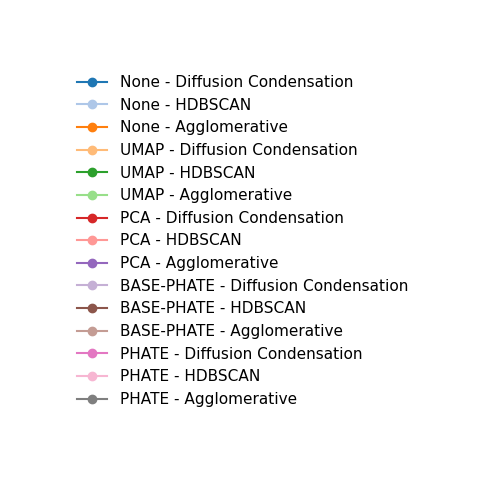

In [40]:
import os
import matplotlib.pyplot as plt

# Create a dummy figure just for the legend
fig, ax = plt.subplots(figsize=(6,6))

lines = []
labels = []

for combo_key, color in combo_color_map.items():

    method, cluster = combo_key.split("_", 1)
    label = f"{method} - {cluster}"

    print(label)

    line, = ax.plot([], [], marker='o', color=color, label=label)

    lines.append(line)
    labels.append(label)

# Create legend
legend = ax.legend(
    handles=lines,
    labels=labels,
    loc='center',
    frameon=False,
    fontsize=11
)

# Hide axes
ax.axis('off')

# Create folder
os.makedirs('legend_only_plots', exist_ok=True)

# Save legend image
legend_file = 'legend_only_plots/legend_methods.png'

fig.savefig(
    legend_file,
    dpi=300,
    bbox_inches='tight',
    transparent=True
)

plt.show()

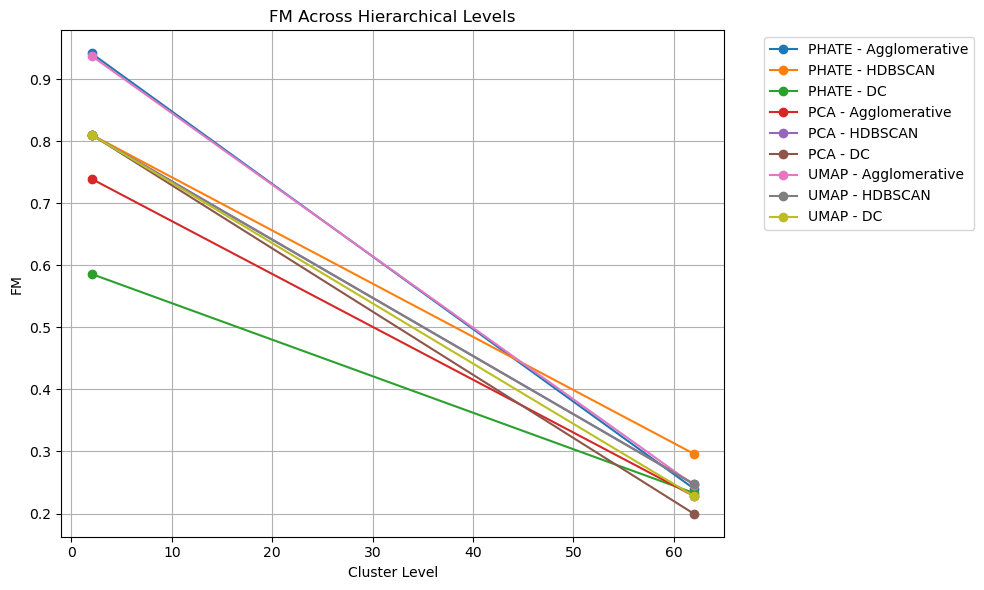

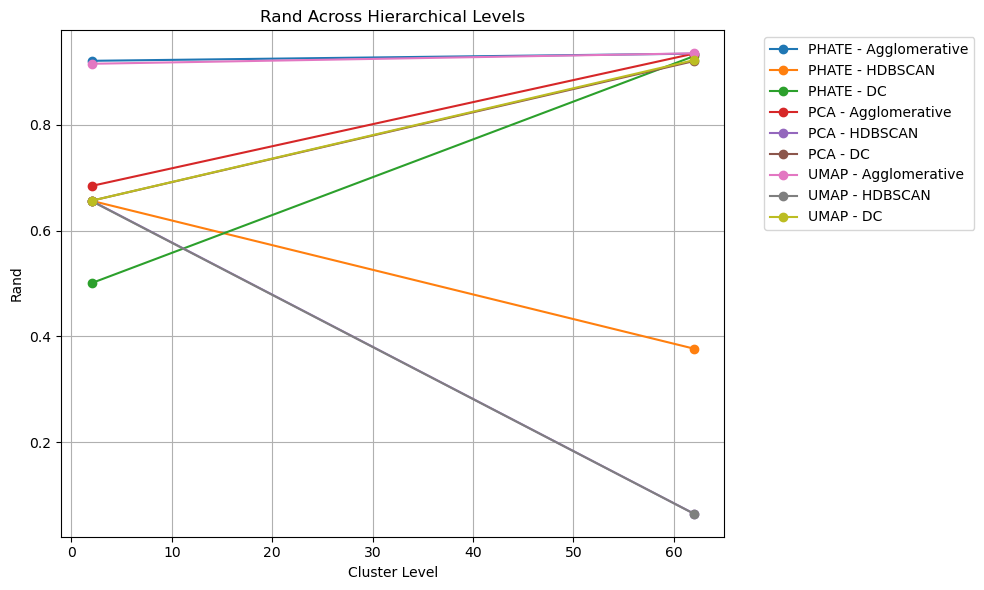

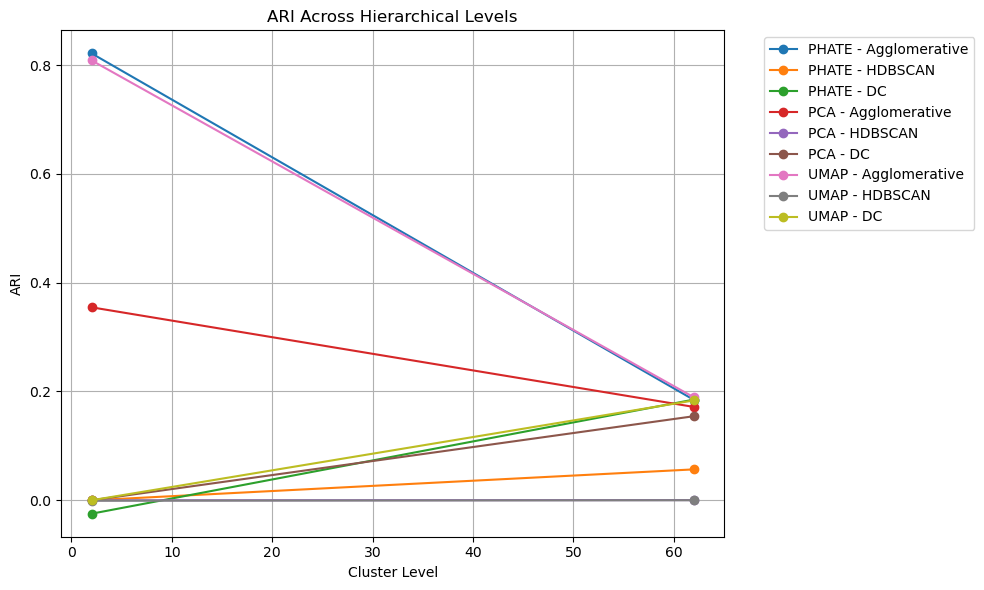

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
for score in ["FM","Rand","ARI"]:

    plt.figure(figsize=(10,6))

    for method in bertopic_results['reduction_method'].unique():
        for cluster in bertopic_results['cluster_method'].unique():

            subset = bertopic_results[
                (bertopic_results['reduction_method']==method) &
                (bertopic_results['cluster_method']==cluster)
            ]

            if subset.empty:
                continue

            subset = subset.sort_values("level")

            label = f"{method} - {cluster}"

            plt.plot(
                subset["level"],
                subset[score],
                marker="o",
                label=label
            )

    plt.xlabel("Cluster Level")
    plt.ylabel(score)
    plt.title(f"{score} Across Hierarchical Levels")

    plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")

    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Summary of Visualization Choice
In this analysis, boxplots were not used because the dataset does not contain multiple observations for each method and hierarchical level combination. Boxplots are typically used to visualize the distribution of values when there are many observations per group (for example, multiple runs, seeds, or trials). In this case, the results dataset contains only a single evaluation score for each combination of dimensionality reduction method, clustering algorithm, and hierarchical level.
The dataset has the following structure:
reduction_method: dimensionality reduction technique (PCA, UMAP, PHATE)
cluster_method: clustering algorithm (Agglomerative, Diffusion Condensation, HDBSCAN)

level: hierarchical clustering level (Level 2 and Level 62)
evaluation metrics: FM, Rand, and ARI scores
Each method–cluster pair only has one score per hierarchical level, meaning there is no distribution of values to summarize with a boxplot. Because of this, a boxplot would collapse to a single line rather than showing quartiles, medians, and variability.
Instead, line plots were used to visualize how clustering performance changes across hierarchical levels. Line plots are more appropriate for this dataset because they clearly show the change in performance from coarse clusters (Level 2) to fine-grained clusters (Level 62) for each method combination. This allows for direct comparison of how different dimensionality reduction and clustering techniques perform as the hierarchy becomes more detailed.
Overall, this visualization approach better reflects the structure of the dataset and highlights the key trend in the results: clustering performance generally decreases as the hierarchical level increases and clusters become more granular.

# Hierarchical metrics such as LCA-F1 and Tree Edit Distance were not applied to the arXiv dataset.

These metrics require a hierarchical ground-truth taxonomy. The arXiv benchmark dataset provides flat topic labels rather than hierarchical labels, which prevents the construction of a reference hierarchy for evaluation.

Therefore, the evaluation for arXiv focuses on flat clustering metrics including:
- Adjusted Rand Index (ARI)
- Adjusted Mutual Information (AMI)
- Fowlkes–Mallows (FM)
- Rand Index

Hierarchical metrics are instead applied to the synthetic hierarchical datasets (Fisheries and Ecosystems) where ground-truth hierarchies are available.